# 05 - Editorial Bias Analysis

**Question:** Do individual Bandcamp Daily writers have measurable, systematic
preferences — or does the section's coverage look like one editorial voice?

This matters commercially, not just as trivia. Editorial coverage is
discovery: if a handful of writers each reliably champion a specific sound or
scene, then *which writer gets assigned* materially affects which artists get
surfaced. That is exactly the question a music company's editorial or curation
team asks about its own playlist editors.

### A note on the word "bias"

Used here in the statistical sense — a systematic deviation from the site
average — not as an accusation. A specialist writer covering the genre they
know best is a feature of good editorial, not a flaw. What follows measures
the effect; interpreting it is a separate judgement.

### Scope

Restricted to the **top 15 contributors by review count**. Comparing a writer
with four reviews against one with 110 produces noise, not insight.

In [1]:
import sys
from pathlib import Path

# Make the pipeline package importable without installing it, so the notebook
# runs on a fresh clone. `pip install -e .` also works and is preferred.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from bandcamp_aotd.logging_config import setup_logging

setup_logging()

In [2]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, entropy as scipy_entropy

from bandcamp_aotd import config

sns.set_theme(style="whitegrid")
ACCENT = "#629aa9"

df = pd.read_csv(config.ANALYTICS_CSV, parse_dates=["published_date"])

TOP_N = 15
top_authors = df["author"].value_counts().head(TOP_N).index
df_top = df[df["author"].isin(top_authors)].copy()

print(f"{len(df_top):,} reviews by the top {TOP_N} contributors "
      f"({len(df_top) / len(df):.0%} of the archive)")
df["author"].value_counts().head(TOP_N)

674 reviews by the top 15 contributors (29% of the archive)


author
John Morrison          110
J. Edward Keyes         54
Elle Carroll            49
Amaya Garcia            48
Andrew Parks            46
Dean Van Nguyen         39
Jim Allen               39
Phillip Mlynar          39
Marcus J. Moore         38
Andy Beta               37
Joe Muggs               37
Ted Davis               37
Ben Salmon              34
James Gui               34
Max Savage Levenson     33
Name: count, dtype: int64

## 1. Genre concentration

Row-normalised, so each row is one writer's genre mix as a percentage of their
own output. Reading down a column shows which writers over-index on a genre;
reading across a row shows how spread out a writer is.

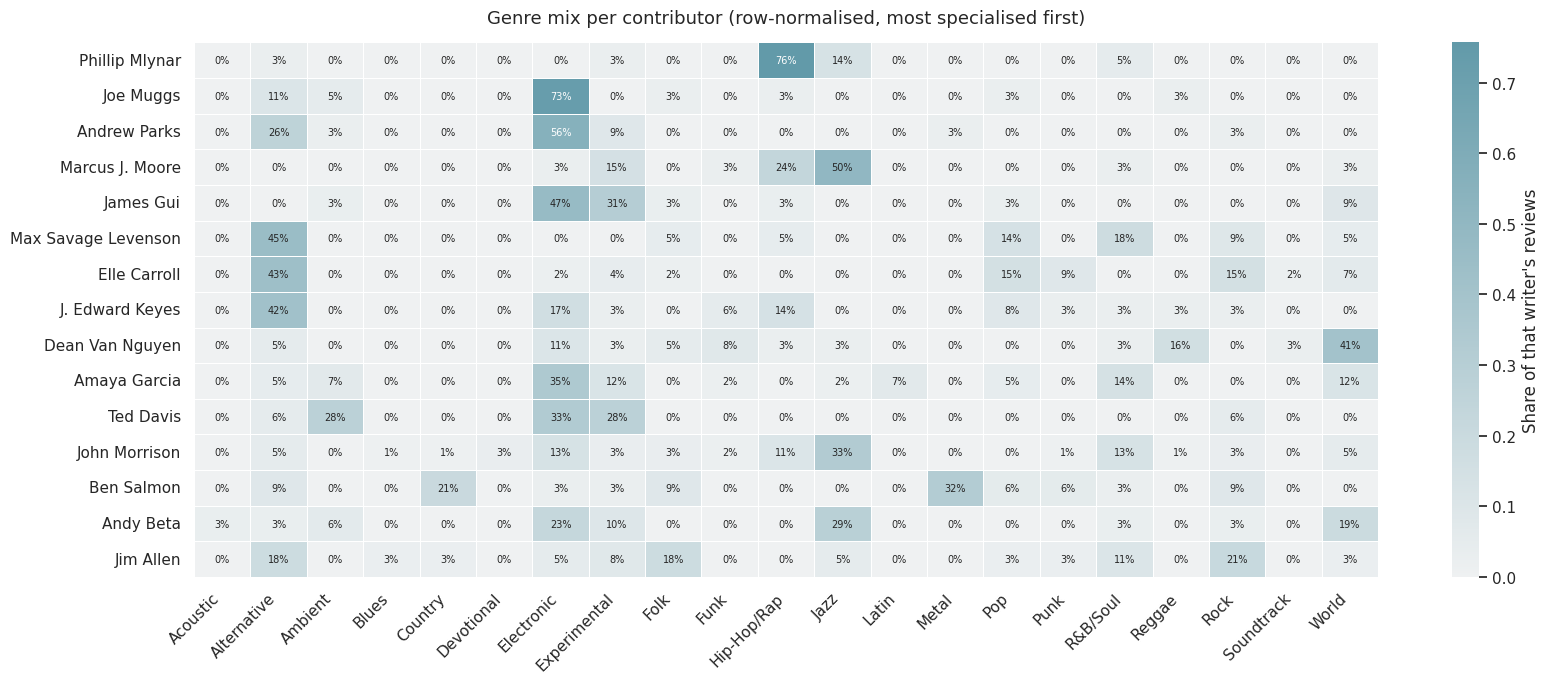

In [3]:
genre_counts = df_top.groupby(["author", "genre_tag"]).size().unstack(fill_value=0)
genre_norm = genre_counts.div(genre_counts.sum(axis=1), axis=0)

# Order writers by how concentrated they are — most specialised at the top.
order = genre_norm.max(axis=1).sort_values(ascending=False).index
genre_norm = genre_norm.loc[order]

fig, ax = plt.subplots(figsize=(17, 7))
sns.heatmap(
    genre_norm,
    cmap=sns.light_palette(ACCENT, as_cmap=True),
    annot=True, fmt=".0%", annot_kws={"fontsize": 7},
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Share of that writer's reviews"},
    ax=ax,
)
ax.set_title("Genre mix per contributor (row-normalised, most specialised first)",
             fontsize=13, pad=14)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 2. Is the difference statistically significant?

The heatmap shows differences exist. A chi-square goodness-of-fit test asks
whether they're larger than sampling noise would produce — comparing each
writer's genre distribution against the archive-wide distribution.

**Caveats, stated up front:**

- Fifteen tests are run without a multiple-comparison correction. Bonferroni
  at α=0.05 would demand p < 0.0033; the raw p-values are shown so both
  thresholds can be read off.
- Chi-square assumes expected cell counts of roughly 5 or more. With 25 genre
  tags and some writers having under 40 reviews, sparse cells make individual
  p-values approximate. The test is used to *rank* writers by deviation, not
  to make a precise claim about any single one.

In [4]:
overall_genre = df["genre_tag"].value_counts()

results = []
for author in top_authors:
    author_genre = df_top.loc[df_top["author"] == author, "genre_tag"].value_counts()
    combined = pd.DataFrame({"author": author_genre, "overall": overall_genre}).fillna(0)
    if len(combined) > 1:
        chi2, p, dof, _ = chi2_contingency(combined.T)
        results.append({
            "Author": author,
            "Reviews": int(overall_genre.index.size and df["author"].value_counts()[author]),
            "chi2": round(chi2, 1),
            "p_value": p,
            "p<0.05": p < 0.05,
            "p<0.0033 (Bonferroni)": p < 0.05 / TOP_N,
        })

chi_df = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)
chi_df["p_value"] = chi_df["p_value"].map(lambda v: f"{v:.2e}")
chi_df

,Author,Reviews,chi2,p_value,p<0.05,p<0.0033 (Bonferroni)
0,Phillip Mlynar,39,212.3,4.26e-32,True,True
1,Dean Van Nguyen,39,195.5,7.61e-29,True,True
2,Ben Salmon,34,179.9,7.54e-26,True,True
3,John Morrison,110,137.4,6.96e-18,True,True
4,Marcus J. Moore,38,105.5,3.35e-12,True,True
5,Ted Davis,37,89.8,1.54e-09,True,True
6,Joe Muggs,37,89.0,2.07e-09,True,True
7,Jim Allen,39,74.6,4.32e-07,True,True
8,Elle Carroll,49,70.3,2.00e-06,True,True
9,Amaya Garcia,48,59.4,7.66e-05,True,True


## 3. Diversity, measured properly

A count of distinct genres is a bad diversity measure: a writer with 14 genres
where 90% of reviews sit in one of them is not diverse. Shannon entropy
weights by how evenly the reviews are spread.

Read in bits. 0 = every review in one genre. Higher = more evenly spread. The
theoretical maximum across 25 tags is log₂(25) ≈ 4.6 bits.

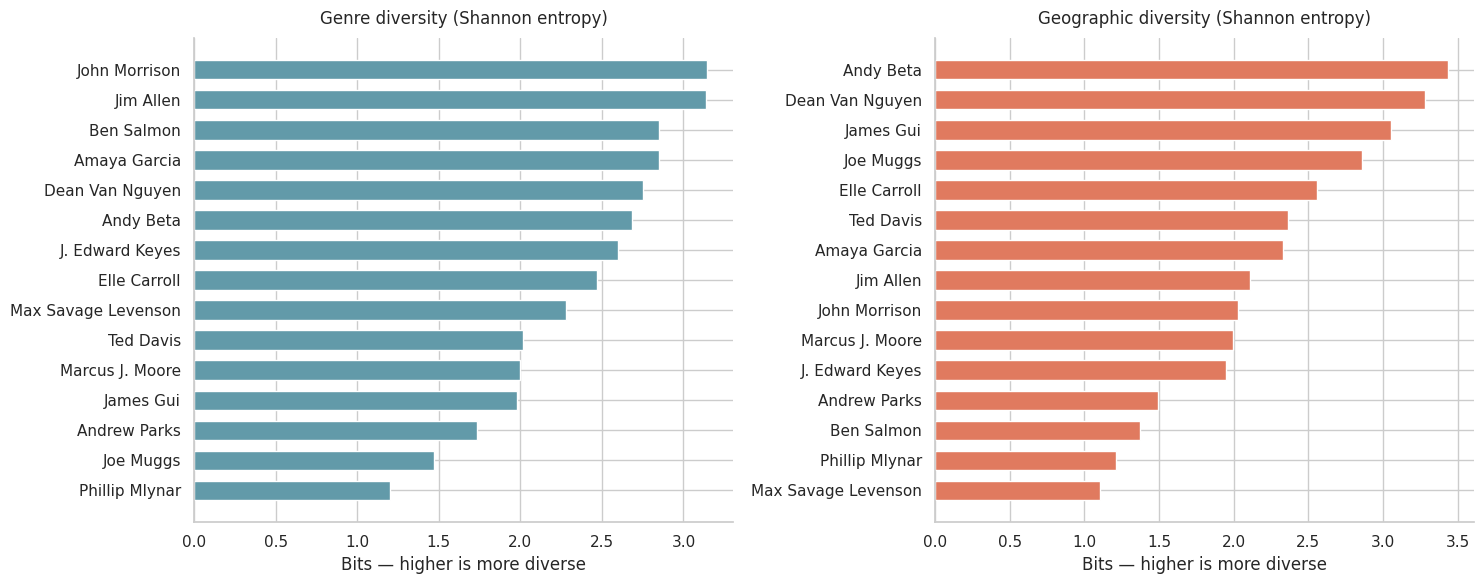

,author,genre_entropy,geo_entropy,reviews
10,John Morrison,3.15,2.03,110
8,Jim Allen,3.14,2.11,39
3,Ben Salmon,2.85,1.38,34
0,Amaya Garcia,2.85,2.33,48
4,Dean Van Nguyen,2.75,3.28,39
2,Andy Beta,2.68,3.44,37
6,J. Edward Keyes,2.60,1.95,54
5,Elle Carroll,2.47,2.56,49
12,Max Savage Levenson,2.28,1.11,33
14,Ted Davis,2.02,2.36,37


In [5]:
def shannon_bits(series):
    return scipy_entropy(series.value_counts(normalize=True), base=2)

scores = (
    df_top.groupby("author")
    .agg(
        genre_entropy=("genre_tag", shannon_bits),
        geo_entropy=("country", shannon_bits),
        reviews=("album", "count"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (col, title, color) in zip(axes, [
    ("genre_entropy", "Genre diversity", ACCENT),
    ("geo_entropy", "Geographic diversity", "#e07a5f"),
]):
    ordered = scores.sort_values(col)
    ax.barh(ordered["author"], ordered[col], color=color, height=0.65)
    ax.set_title(f"{title} (Shannon entropy)", fontsize=12, pad=10)
    ax.set_xlabel("Bits — higher is more diverse")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

scores.sort_values("genre_entropy", ascending=False).round(2)

## 4. Independent-artist preference

Some writers consistently cover self-released records; others gravitate to
label releases. The red line is the site-wide average, so distance from it is
the effect size.

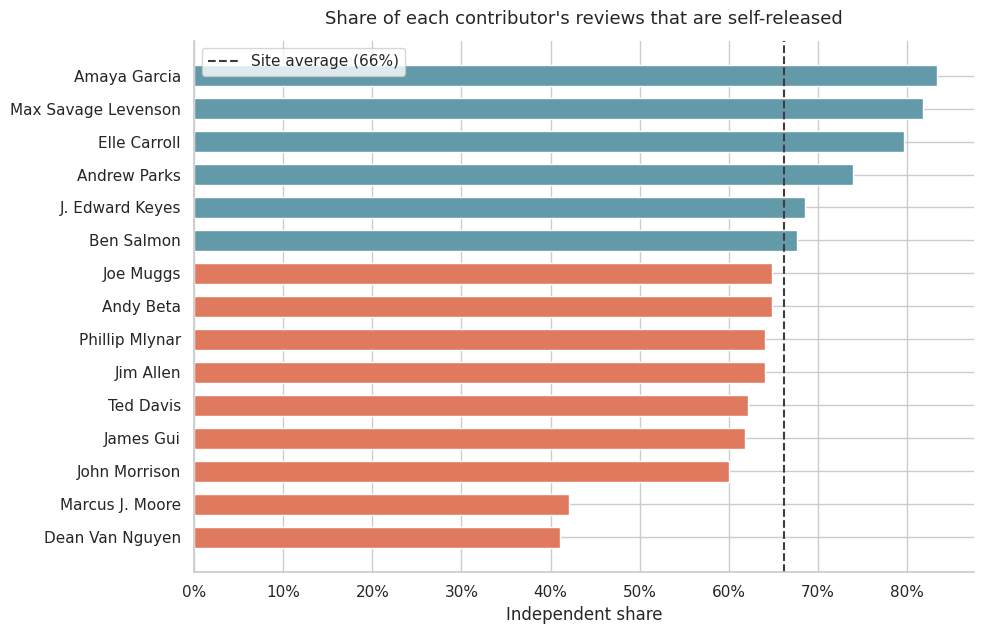

In [6]:
indie = df_top.groupby("author")["is_independent"].mean().sort_values()
baseline = df["is_independent"].mean()

fig, ax = plt.subplots(figsize=(10, 6.5))
colors = ["#e07a5f" if v < baseline else ACCENT for v in indie.values]
ax.barh(indie.index, indie.values, color=colors, height=0.65)
ax.axvline(baseline, color="#3d3d3d", linestyle="--", linewidth=1.5,
           label=f"Site average ({baseline:.0%})")
ax.set_title("Share of each contributor's reviews that are self-released",
             fontsize=13, pad=12)
ax.set_xlabel("Independent share")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Geographic focus

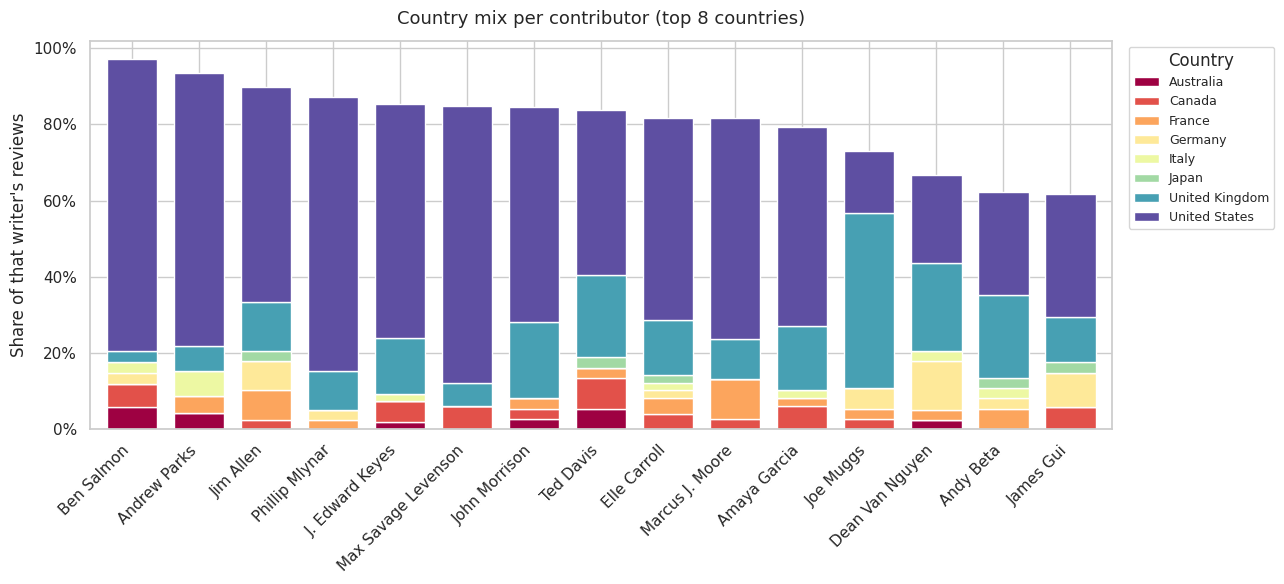

In [7]:
top_countries = df["country"].value_counts().head(8).index
geo = (
    df_top[df_top["country"].isin(top_countries)]
    .groupby(["author", "country"])
    .size()
    .unstack(fill_value=0)
)
geo_share = geo.div(df_top.groupby("author").size(), axis=0).fillna(0)
geo_share = geo_share.loc[geo_share.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 6))
geo_share.plot(kind="bar", stacked=True, ax=ax, colormap="Spectral", width=0.75)
ax.set_title("Country mix per contributor (top 8 countries)", fontsize=13, pad=12)
ax.set_ylabel("Share of that writer's reviews")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title="Country", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Label affinity

For signed releases only: does a writer keep returning to the same label?
Concentration is the share of that writer's signed reviews going to their most
covered label.

In [8]:
signed = df_top[~df_top["is_independent"]].copy()

rows = []
for author in top_authors:
    labels = signed.loc[signed["author"] == author, "record_label"].dropna()
    if len(labels) < 5:
        continue
    counts = labels.value_counts()
    rows.append({
        "Author": author,
        "Top label": counts.idxmax(),
        "Reviews of that label": int(counts.max()),
        "Total signed reviews": len(labels),
        "Concentration": round(counts.max() / len(labels), 3),
    })

pd.DataFrame(rows).sort_values("Concentration", ascending=False).reset_index(drop=True)

,Author,Top label,Reviews of that label,Total signed reviews,Concentration
0,Andrew Parks,MASTER BOOT RECORD,3,12,0.250
1,Max Savage Levenson,OIM Records,1,6,0.167
2,James Gui,Bilna'es بالناقص,2,13,0.154
3,Ted Davis,DAWN,2,14,0.143
4,Phillip Mlynar,YUNGMORPHEUS,2,14,0.143
5,Jim Allen,BYG Records,2,14,0.143
6,Marcus J. Moore,International Anthem,3,22,0.136
7,Dean Van Nguyen,Analog Africa,3,23,0.130
8,Amaya Garcia,Spacetalk,1,8,0.125
9,John Morrison,International Anthem,5,44,0.114


## 7. Who was writing when

Contributor turnover is its own explanation for shifts in coverage: a genre
can appear to decline simply because the writer who covered it stopped
contributing. Worth checking before attributing any trend to editorial
strategy.

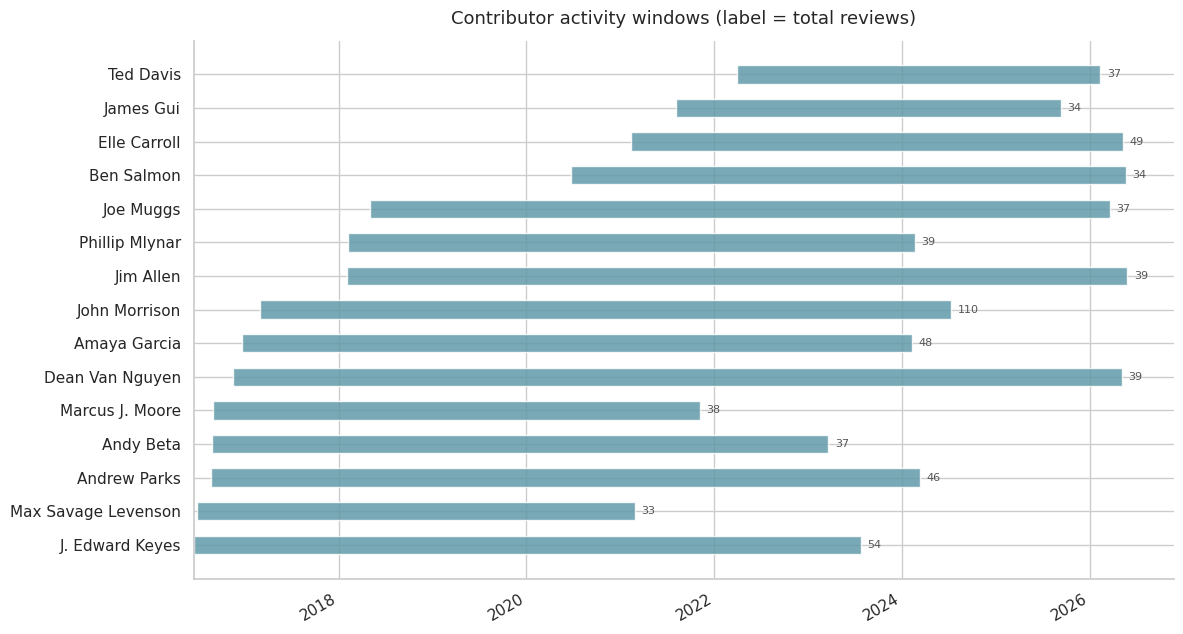

In [9]:
activity = (
    df_top.groupby("author")["published_date"]
    .agg(first="min", last="max", reviews="count")
    .sort_values("first")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6.5))
for i, row in activity.iterrows():
    ax.barh(
        y=i,
        width=(row["last"] - row["first"]).days,
        left=mdates.date2num(row["first"]),
        height=0.55, color=ACCENT, alpha=0.85,
    )
    ax.text(mdates.date2num(row["last"]) + 25, i, str(int(row["reviews"])),
            va="center", fontsize=8, color="#555")

ax.set_yticks(range(len(activity)))
ax.set_yticklabels(activity["author"])
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Contributor activity windows (label = total reviews)", fontsize=13, pad=12)
ax.spines[["top", "right"]].set_visible(False)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## What this establishes

Writers at Bandcamp Daily are measurably specialised — in genre, in geography,
and in their appetite for self-released work. The chi-square results say those
differences are larger than chance for most of the top contributors, and the
entropy scores put a number on how concentrated each writer is.

**What it does not establish.** This is observational data with no assignment
mechanism visible. A writer's genre concentration could reflect their own
taste, an editor assigning them to their specialism, or the mix of what was
submitted while they happened to be active. Separating those would need the
assignment data, which isn't public.

The honest framing for a stakeholder: *coverage is concentrated by writer, and
here is how much* — not *writers are biased*.